# Seattle Public Library Physical and Digital Checkout Trends

Analysis question: How have Seattle Public Library physical vs. digital checkout totals changed across complete years, and which recent complete year shows the largest digital share?

## Data and Row Meaning

This analysis uses only `seattle-public-library/combined_checkout_totals_by_month_usageclass.csv`. According to the project schema reference, one row represents one `usageclass` in one month of one year. The file is an aggregated monthly total, not title-level sample data.

Before comparing years, the notebook keeps only complete years: years with all 12 months present for both `physical` and `digital` rows.

In [1]:
from pathlib import Path

import pandas as pd

DATA_PATH = Path("../../seattle-public-library/combined_checkout_totals_by_month_usageclass.csv")
ASSET_DIR = Path("reports/assets")
ASSET_DIR.mkdir(parents=True, exist_ok=True)

checkout_months = pd.read_csv(DATA_PATH)
checkout_months["usageclass_clean"] = checkout_months["usageclass"].str.strip().str.lower()

expected_columns = [
    "checkout_year",
    "checkout_month",
    "usageclass",
    "total_checkouts",
    "month_total_checkouts",
    "usageclass_share",
    "title_month_rows",
    "sample_rows",
]

missing_columns = []
for column_name in expected_columns:
    if column_name not in checkout_months.columns:
        missing_columns.append(column_name)

print(f"Rows loaded: {len(checkout_months):,}")
print(f"Columns match expected schema: {missing_columns == []}")
print(f"Missing columns: {missing_columns}")
print(f"Raw usage classes: {sorted(checkout_months['usageclass'].dropna().unique())}")
print(f"Normalized usage classes: {sorted(checkout_months['usageclass_clean'].dropna().unique())}")
print(f"Year range: {checkout_months['checkout_year'].min()}-{checkout_months['checkout_year'].max()}")

checkout_months.head()

Rows loaded: 501
Columns match expected schema: True
Missing columns: []
Raw usage classes: ['Digital', 'Physical']
Normalized usage classes: ['digital', 'physical']
Year range: 2005-2026


,checkout_year,checkout_month,usageclass,total_checkouts,month_total_checkouts,usageclass_share,title_month_rows,sample_rows,usageclass_clean
0,2005,4,Physical,252663,252663,1.0,117681,0,physical
1,2005,5,Physical,401395,401395,1.0,148224,0,physical
2,2005,6,Physical,502439,502439,1.0,160575,0,physical
3,2005,7,Physical,343668,343668,1.0,132711,0,physical
4,2005,8,Physical,373707,373707,1.0,137500,0,physical


## Complete-Year Annual Comparison

The comparison below uses `total_checkouts`, because each source row is already the monthly total for one usage class. A year is included only when both `physical` and `digital` have 12 distinct months in the totals file.

In [2]:
usage_classes_to_compare = ["physical", "digital"]

physical_digital_months = checkout_months[
    checkout_months["usageclass_clean"].isin(usage_classes_to_compare)
].copy()

monthly_completeness = (
    physical_digital_months
    .groupby(["checkout_year", "usageclass_clean"], as_index=False)
    .agg(month_count=("checkout_month", "nunique"))
)

complete_year_check = monthly_completeness.pivot(
    index="checkout_year",
    columns="usageclass_clean",
    values="month_count",
).reset_index()

complete_year_check["has_12_physical_months"] = complete_year_check["physical"] == 12
complete_year_check["has_12_digital_months"] = complete_year_check["digital"] == 12
complete_year_check["is_complete_for_both"] = (
    complete_year_check["has_12_physical_months"]
    & complete_year_check["has_12_digital_months"]
)

complete_years = complete_year_check.loc[
    complete_year_check["is_complete_for_both"],
    "checkout_year",
].tolist()

complete_year_months = physical_digital_months[
    physical_digital_months["checkout_year"].isin(complete_years)
].copy()

annual_totals_long = (
    complete_year_months
    .groupby(["checkout_year", "usageclass_clean"], as_index=False)
    .agg(annual_checkouts=("total_checkouts", "sum"))
)

annual_totals = annual_totals_long.pivot(
    index="checkout_year",
    columns="usageclass_clean",
    values="annual_checkouts",
).reset_index()

annual_totals["all_physical_digital_checkouts"] = (
    annual_totals["physical"] + annual_totals["digital"]
)
annual_totals["digital_share"] = (
    annual_totals["digital"] / annual_totals["all_physical_digital_checkouts"]
)
annual_totals["physical_share"] = (
    annual_totals["physical"] / annual_totals["all_physical_digital_checkouts"]
)
annual_totals["digital_change_from_previous_complete_year"] = annual_totals["digital"].diff()
annual_totals["physical_change_from_previous_complete_year"] = annual_totals["physical"].diff()

recent_complete_years = annual_totals["checkout_year"].tail(5).tolist()
recent_annual_totals = annual_totals[
    annual_totals["checkout_year"].isin(recent_complete_years)
].copy()

largest_recent_digital_share = recent_annual_totals.sort_values(
    "digital_share",
    ascending=False,
).head(1)

annual_table_path = ASSET_DIR / "annual_physical_digital_complete_years.csv"
annual_totals.to_csv(annual_table_path, index=False)

print(f"Complete years included: {min(complete_years)}-{max(complete_years)}")
print(f"Number of complete years: {len(complete_years)}")
print(f"Recent complete years checked: {recent_complete_years}")
print(f"Saved annual table: {annual_table_path}")

first_complete_year = annual_totals.iloc[0]
latest_complete_year = annual_totals.iloc[-1]

print(
    "First complete year: "
    f"{int(first_complete_year['checkout_year'])}, "
    f"physical {int(first_complete_year['physical']):,}, "
    f"digital {int(first_complete_year['digital']):,}, "
    f"digital share {first_complete_year['digital_share']:.1%}"
)
print(
    "Latest complete year: "
    f"{int(latest_complete_year['checkout_year'])}, "
    f"physical {int(latest_complete_year['physical']):,}, "
    f"digital {int(latest_complete_year['digital']):,}, "
    f"digital share {latest_complete_year['digital_share']:.1%}"
)

annual_totals.tail(10)

Complete years included: 2006-2025
Number of complete years: 20
Recent complete years checked: [2021, 2022, 2023, 2024, 2025]
Saved annual table: reports/assets/annual_physical_digital_complete_years.csv
First complete year: 2006, physical 6,582,479, digital 16,839, digital share 0.3%
Latest complete year: 2025, physical 3,436,853, digital 6,076,196, digital share 63.9%


usageclass_clean,checkout_year,digital,physical,all_physical_digital_checkouts,digital_share,physical_share,digital_change_from_previous_complete_year,physical_change_from_previous_complete_year
10,2016,2452733,6568318,9021051,0.271890,0.728110,240180.0,-303308.0
11,2017,2752214,6479434,9231648,0.298128,0.701872,299481.0,-88884.0
12,2018,3046521,6102655,9149176,0.332983,0.667017,294307.0,-376779.0
13,2019,3430759,5768324,9199083,0.372946,0.627054,384238.0,-334331.0
14,2020,4310016,1743701,6053717,0.711962,0.288038,879257.0,-4024623.0
15,2021,4394381,2966650,7361031,0.596979,0.403021,84365.0,1222949.0
16,2022,4692195,3710181,8402376,0.558437,0.441563,297814.0,743531.0
17,2023,5476658,3720574,9197232,0.595468,0.404532,784463.0,10393.0
18,2024,5366644,2954034,8320678,0.644977,0.355023,-110014.0,-766540.0
19,2025,6076196,3436853,9513049,0.638722,0.361278,709552.0,482819.0


Saved chart: reports/assets/annual_physical_digital_checkout_trends.png


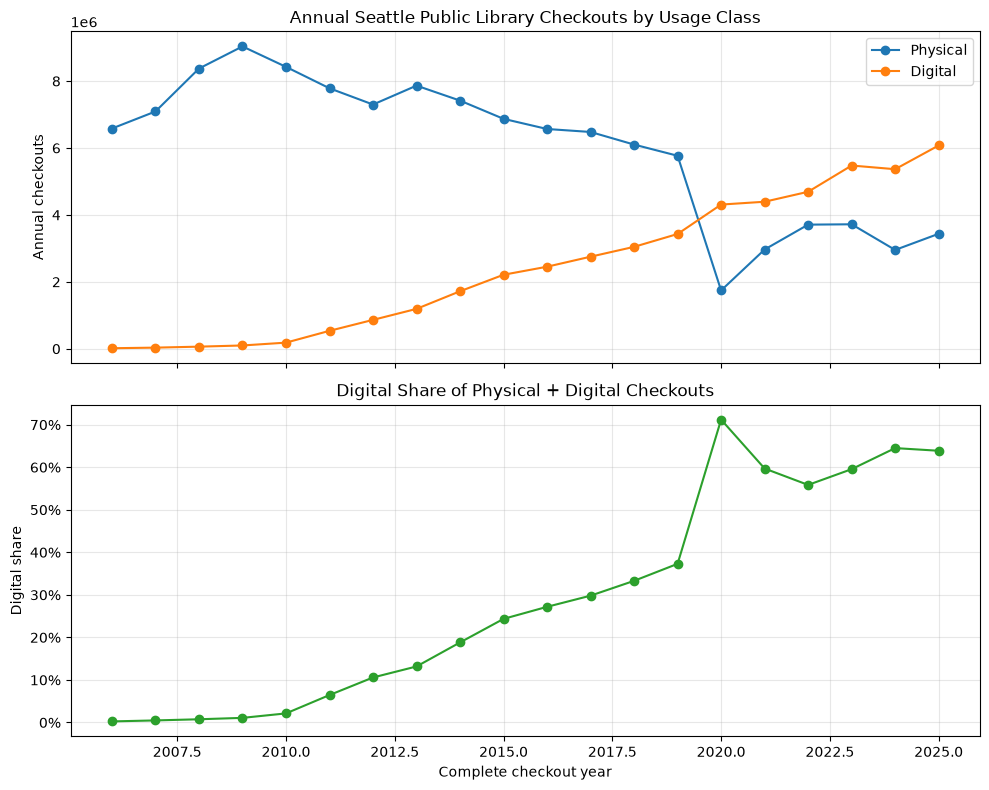

In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

chart_data = annual_totals.copy()
chart_data["digital_share_percent"] = chart_data["digital_share"] * 100

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(
    chart_data["checkout_year"],
    chart_data["physical"],
    marker="o",
    label="Physical",
)
axes[0].plot(
    chart_data["checkout_year"],
    chart_data["digital"],
    marker="o",
    label="Digital",
)
axes[0].set_title("Annual Seattle Public Library Checkouts by Usage Class")
axes[0].set_ylabel("Annual checkouts")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    chart_data["checkout_year"],
    chart_data["digital_share"],
    color="tab:green",
    marker="o",
)
axes[1].set_title("Digital Share of Physical + Digital Checkouts")
axes[1].set_xlabel("Complete checkout year")
axes[1].set_ylabel("Digital share")
axes[1].yaxis.set_major_formatter(PercentFormatter(xmax=1))
axes[1].grid(True, alpha=0.3)

fig.tight_layout()

chart_path = ASSET_DIR / "annual_physical_digital_checkout_trends.png"
fig.savefig(chart_path, dpi=160, bbox_inches="tight")

print(f"Saved chart: {chart_path}")
plt.show()

In [4]:
recent_summary = recent_annual_totals[[
    "checkout_year",
    "physical",
    "digital",
    "all_physical_digital_checkouts",
    "digital_share",
]].copy()
recent_summary["digital_share_percent"] = recent_summary["digital_share"] * 100

largest_recent_year = int(largest_recent_digital_share["checkout_year"].iloc[0])
largest_recent_share = float(largest_recent_digital_share["digital_share"].iloc[0])

print(
    "Largest digital share among recent complete years: "
    f"{largest_recent_year} ({largest_recent_share:.1%})"
)

recent_summary

Largest digital share among recent complete years: 2024 (64.5%)


usageclass_clean,checkout_year,physical,digital,all_physical_digital_checkouts,digital_share,digital_share_percent
15,2021,2966650,4394381,7361031,0.596979,59.697901
16,2022,3710181,4692195,8402376,0.558437,55.843669
17,2023,3720574,5476658,9197232,0.595468,59.546807
18,2024,2954034,5366644,8320678,0.644977,64.497677
19,2025,3436853,6076196,9513049,0.638722,63.872224


## Interpretation

The complete-year comparison includes 20 years, from 2006 through 2025. In 2006, Seattle Public Library checkouts in this file were overwhelmingly physical: 6,582,479 physical checkouts compared with 16,839 digital checkouts, for a digital share of 0.3%.

Across the complete years, digital checkouts rose sharply while physical checkouts declined from their earlier levels. By the latest complete year, 2025, the pattern had reversed: digital checkouts reached 6,076,196 and physical checkouts were 3,436,853, giving digital a 63.9% share of combined physical and digital checkouts.

For the recent complete years checked in the notebook (2021-2025), 2024 had the largest digital share at 64.5%. This is slightly higher than 2025's 63.9%, even though 2025 had more digital checkouts, because physical checkouts also increased in 2025.